# Artificial Neural Networks
## Week 3, Day 1 — Object-Oriented Implementation & Conceptual Guide



## Contents

1. [1. Why Neural Networks?](#sec1)
2. [2. From Biology to Code](#sec2)
3. [3. The Perceptron Era](#sec3)
4. [4. Anatomy of a Network](#sec4)
5. [5. The Core Equations](#sec5)
6. [6. Choosing an Activation Function](#sec6)
7. [7. How Data Moves Forward](#sec7)
8. [8. Tuning Knobs (Hyperparameters)](#sec8)
9. [9. Where ANN Shines / Where It Struggles](#sec9)
10. [10. Real-World Deployments](#sec10)
11. [11. Applied Project — Results](#sec11)
12. [12. Wrap-Up](#sec12)
13. [13. Sources](#sec13)



<a id="sec1"></a>
# 1. Why Neural Networks?

Traditional software requires a programmer to write explicit rules for every situation. **Deep Learning** flips this: instead of hand-coding rules, a network is shown many examples and *learns* the rule itself by adjusting internal numeric parameters.

An **Artificial Neural Network (ANN)** is the core structure that makes this learning possible — a stack of simple computational units (neurons) arranged in layers, each performing a small transformation, that together can approximate very complex input → output mappings.

Three reasons this matters in practice:

- **No manual feature design.** A traditional model needs a human to decide which measurements matter; an ANN can discover useful combinations on its own.
- **General-purpose.** The same architecture family handles images, text, audio, and tabular data with only the input/output layers changing.
- **Foundation for everything after it.** CNNs, RNNs, and Transformers are all specialized descendants of the plain ANN covered here.

**Why does this matter beyond convenience?** In classical machine learning, most of the effort goes into *feature engineering* — a domain expert hand-crafts inputs like "edge count" for an image or "average sentence length" for text, and the model only ever sees those crafted numbers. An ANN removes that bottleneck by learning its own intermediate representations layer by layer: early layers might learn something as simple as edges or word co-occurrences, and later layers combine those into increasingly abstract concepts. That's also *why* depth (more layers) tends to help — each layer gets to build on the abstractions the previous layer already discovered, rather than starting from raw pixels or characters every time.


<p align="center">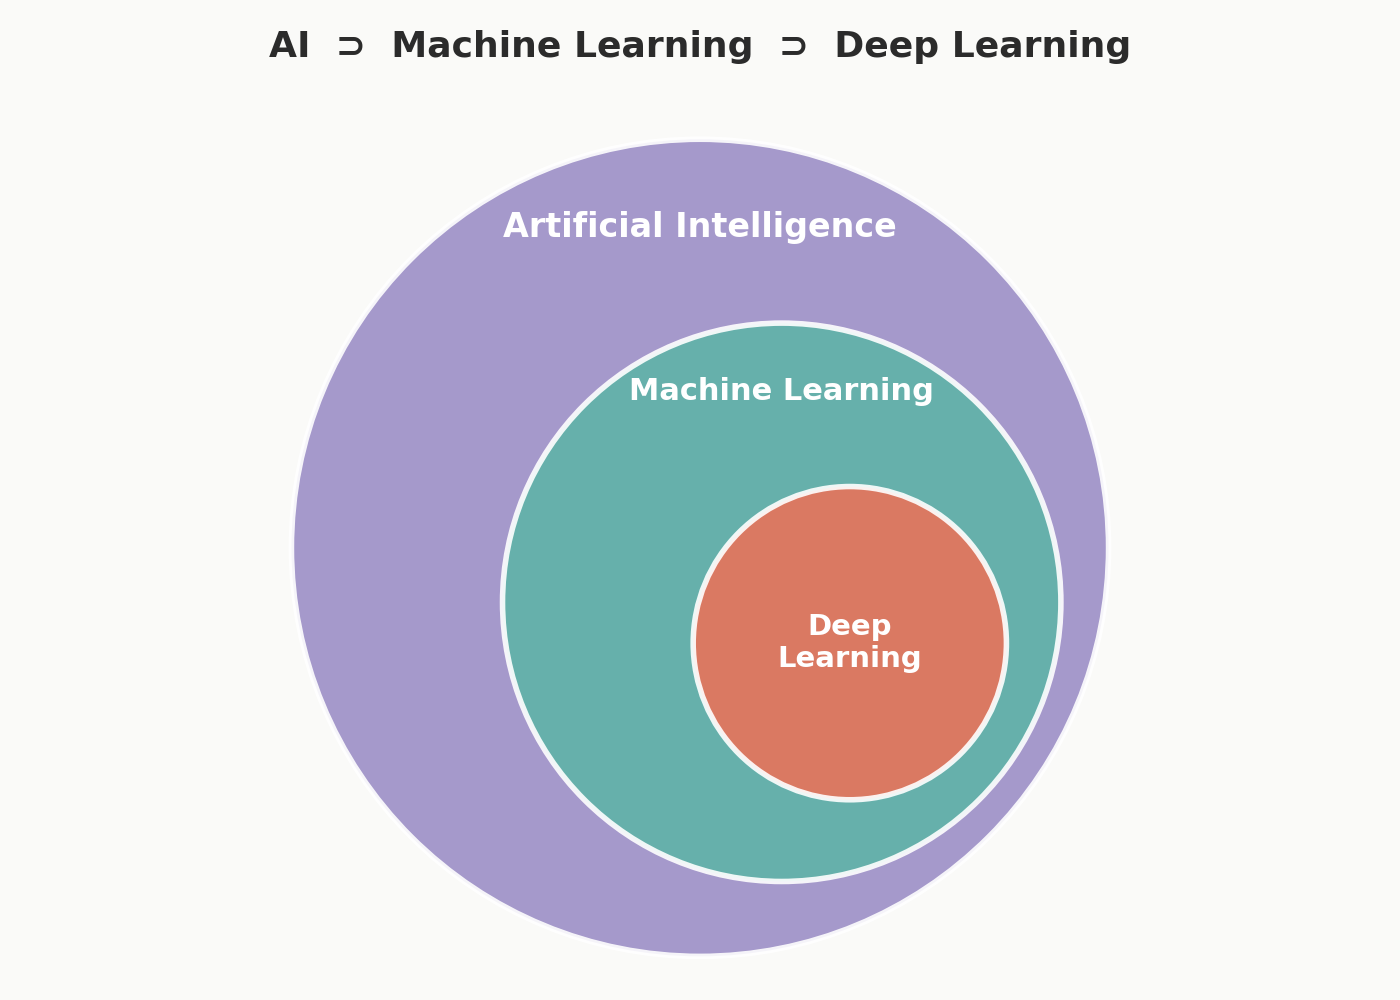</p>
<p align="center"><em>Figure 1. AI contains ML contains Deep Learning.</em></p>


<a id="sec2"></a>
# 2. From Biology to Code

| Stage | Biology | ANN equivalent |
|---|---|---|
| Signal collection | Dendrites gather input from neighboring cells | Input values `x₁ … xₙ` are multiplied by weights |
| Integration | The soma sums incoming charge | A weighted sum `z = Σwᵢxᵢ + b` is computed |
| Firing decision | The cell fires only past a voltage threshold | An activation function `f(z)` decides the output strength |
| Transmission | The axon carries the signal onward | The activated value `a = f(z)` is passed to the next layer |

The name "neural network" is not just branding — it's a direct (if simplified) mapping of this four-stage biological pipeline into arithmetic. A real neuron doesn't fire proportionally to how much charge it receives; it stays silent until a threshold is crossed, then fires. The activation function `f(z)` is the mathematical stand-in for that threshold behaviour — which is exactly why an ANN with no activation function at all cannot learn anything interesting (see Section 6).


<p align="center">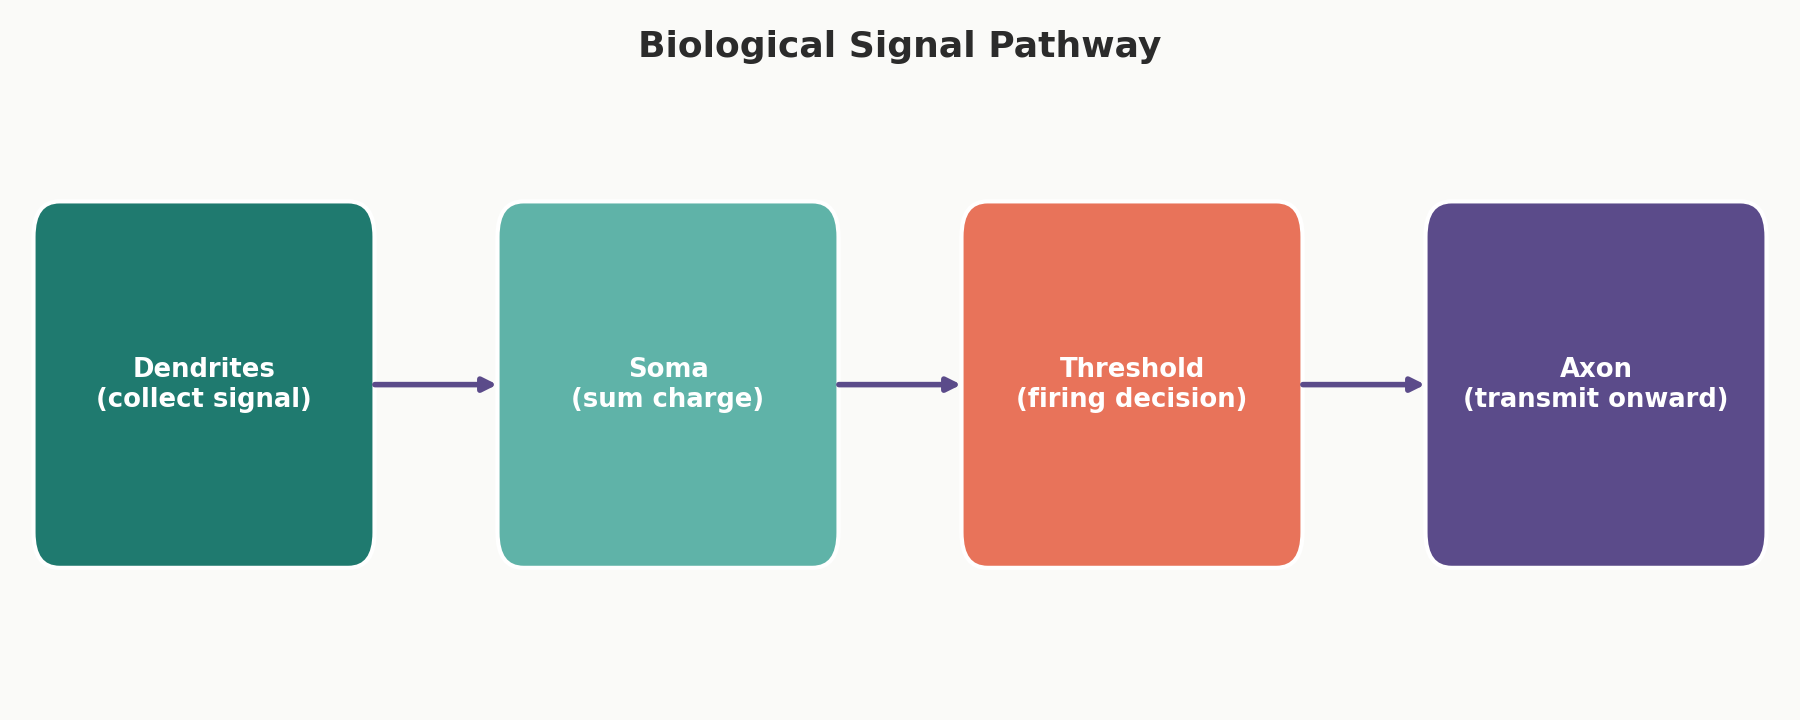</p>
<p align="center"><em>Figure 2. Biological signal pathway.</em></p>


The class `Neuron` in the notebook implements exactly this four-stage pipeline: it stores `weights` and `bias`, and its `.forward(x)` method performs the sum-then-activate sequence in two lines of code.


<p align="center">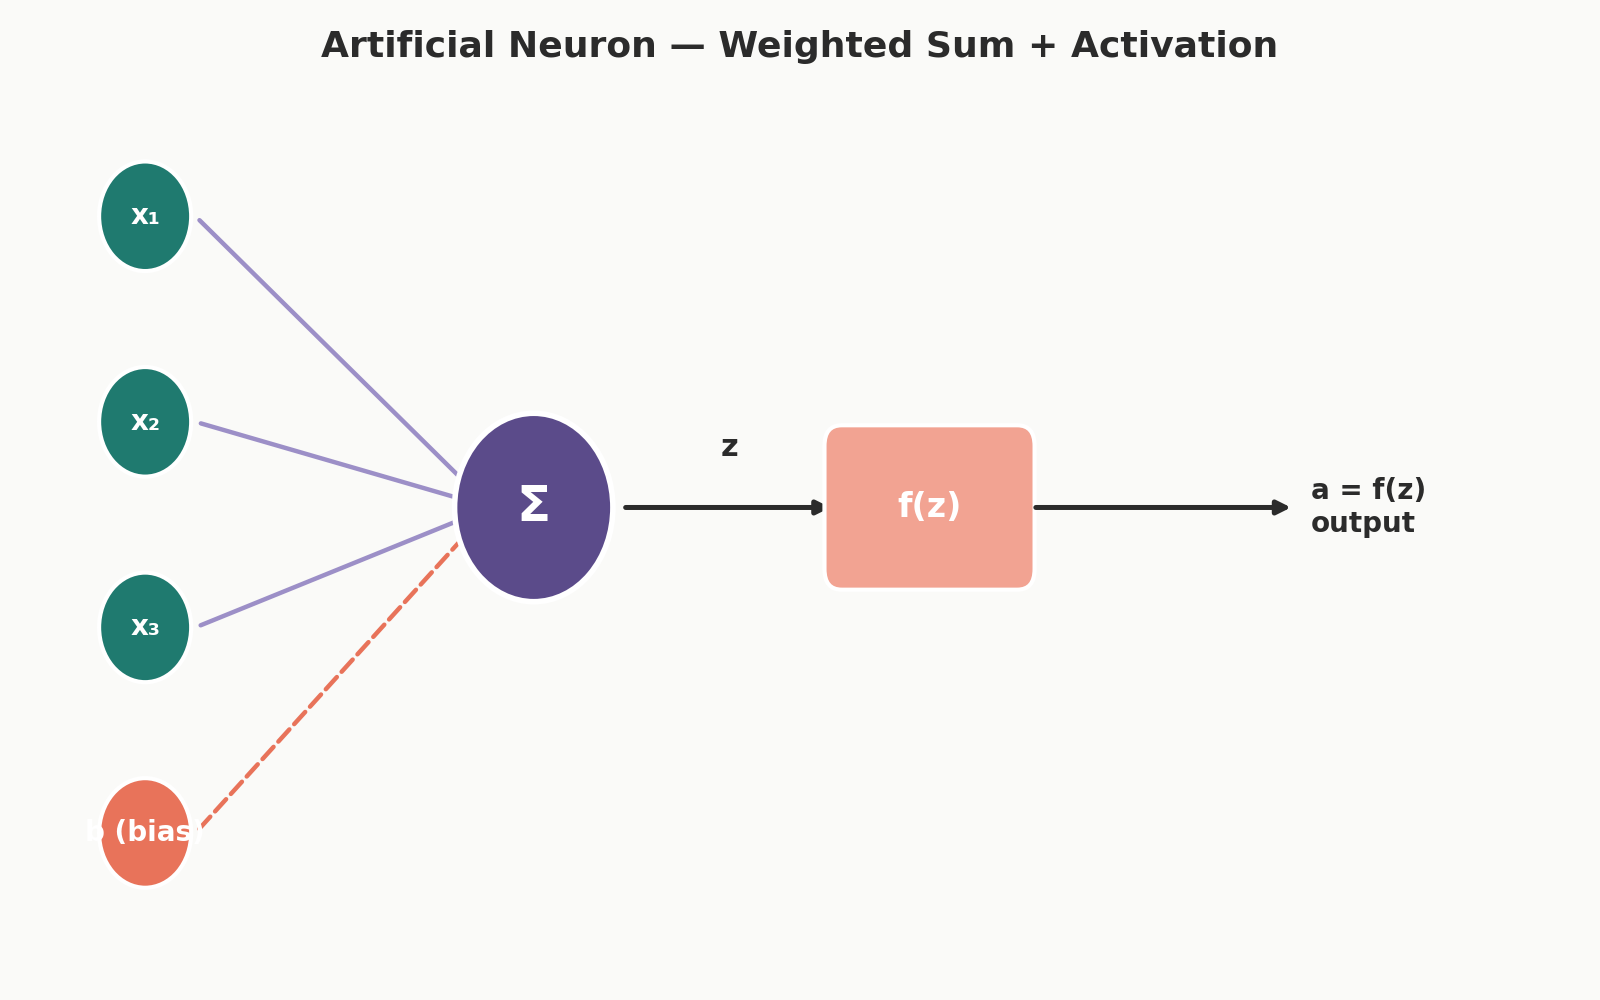</p>
<p align="center"><em>Figure 3. Artificial neuron, top-down view.</em></p>


<a id="sec3"></a>
# 3. The Perceptron Era

The **Perceptron** (Frank Rosenblatt, 1958) was the first algorithm able to *learn* its own weights from labeled examples rather than having them hand-set. Before this, "intelligent" systems needed a human to encode every rule by hand; the perceptron was the first proof that a machine could adjust its own numbers from experience.

**Decision rule** — compute a weighted sum, then apply a hard threshold at zero:

$$
z = \sum_i w_i x_i + b
$$

$$
y =
\begin{cases}
1 & \text{if } z \geq 0 \\
0 & \text{otherwise}
\end{cases}
$$

**Update rule during training** — nudge each weight in the direction that would have reduced the error on this example, scaled by how wrong the prediction was and by a learning rate $\eta$:

$$
w_i \leftarrow w_i + \eta \cdot (y_{\text{true}} - y_{\text{pred}}) \cdot x_i
$$

Notice what this update does intuitively: if the prediction was already correct, $(y_{\text{true}} - y_{\text{pred}}) = 0$ and nothing changes. If the perceptron predicted 0 but should have predicted 1, every weight gets nudged *up* in proportion to its input — making a similar input more likely to cross the threshold next time.


<p align="center">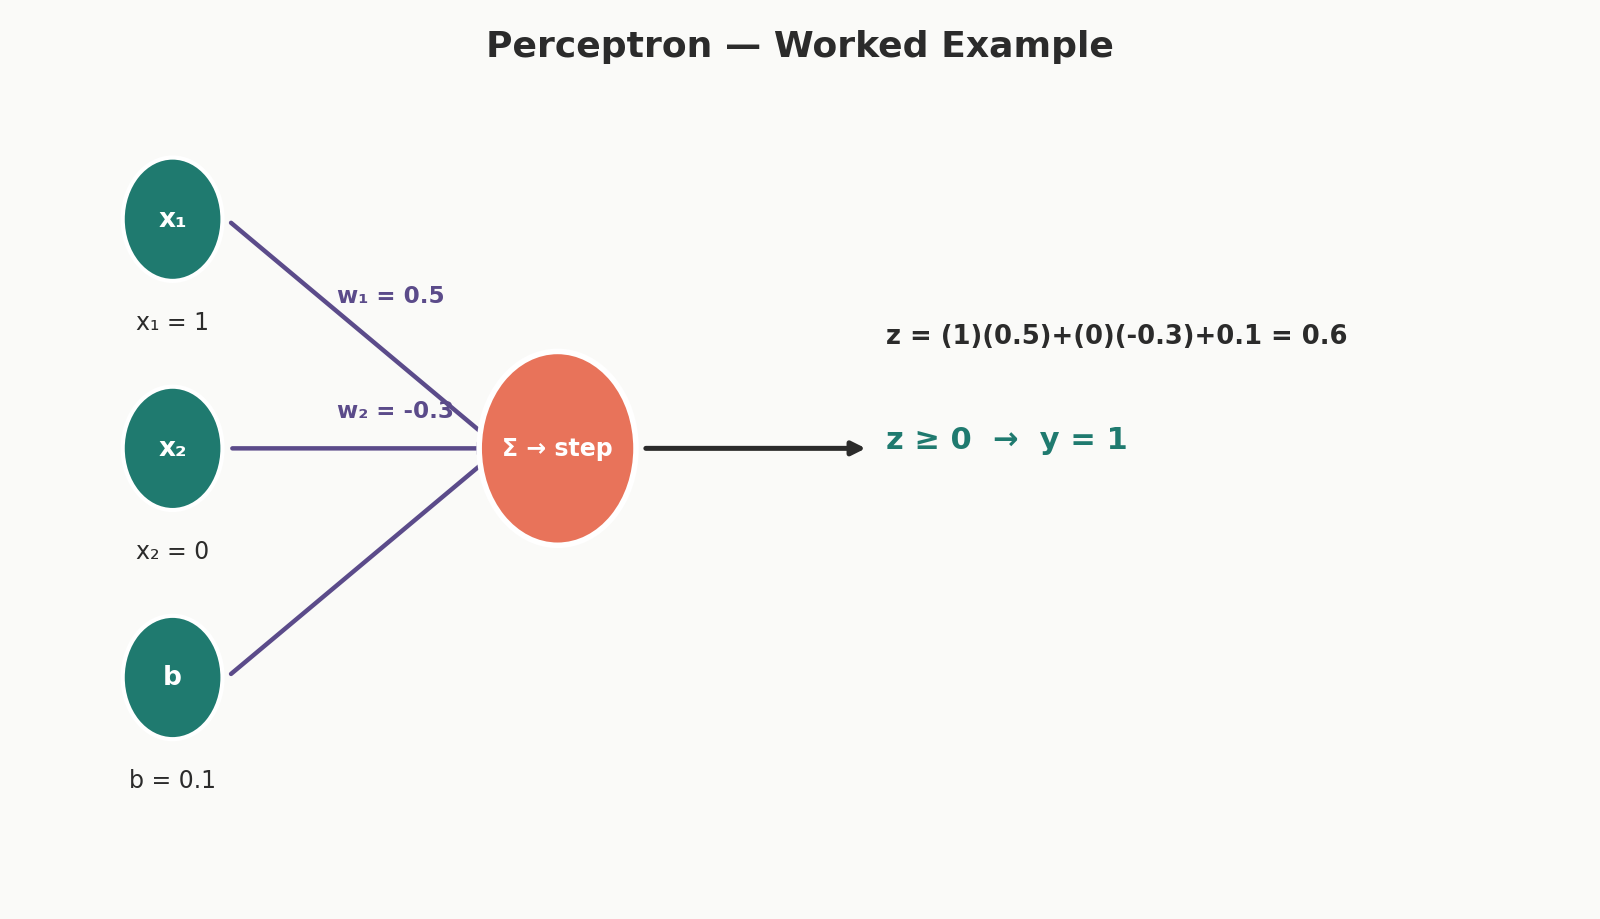</p>
<p align="center"><em>Figure 4. Perceptron with example weights.</em></p>


This worked well for linearly separable problems, but in 1969 Minsky and Papert showed it could never learn the XOR function — a limitation that stalled neural network research for over a decade, until multi-layer networks trained with **backpropagation** (1986) proved capable of learning non-linear boundaries.

**Trade-off summary**

| Strength | Weakness |
|---|---|
| Extremely fast to compute | Only draws a single straight decision boundary |
| Easy to interpret weight-by-weight | Produces a hard 0/1 output, no confidence score |
| Historically important starting point | Cannot represent XOR or similar patterns |


<p align="center">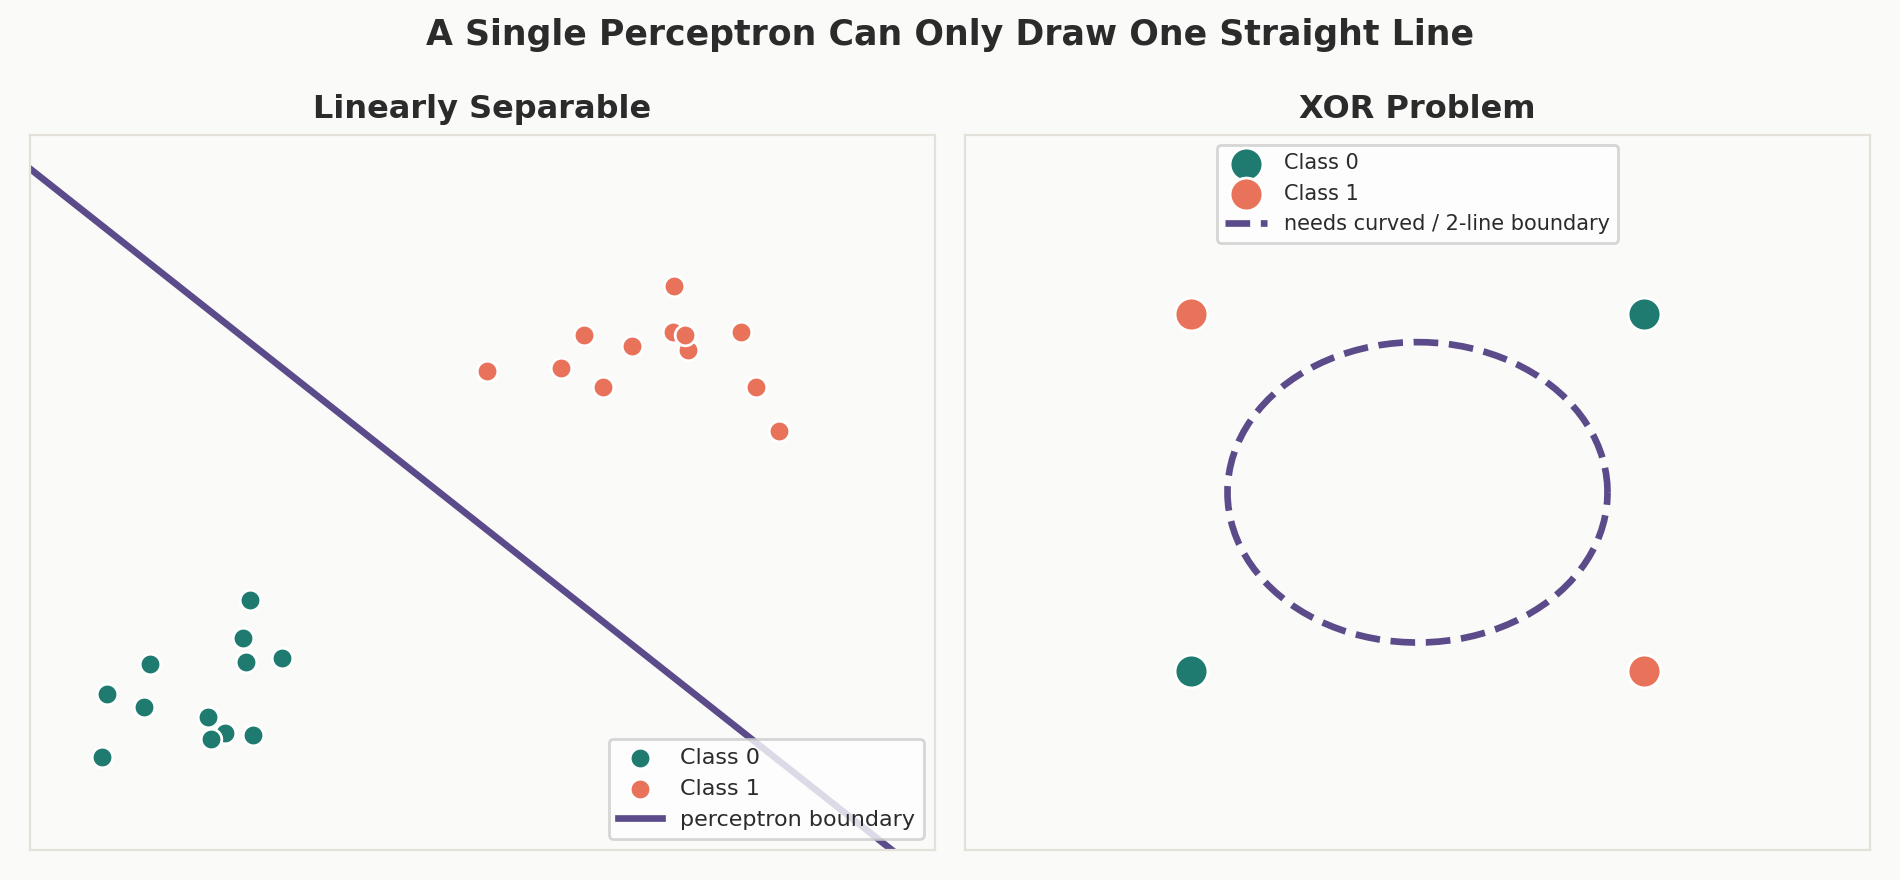</p>
<p align="center"><em>Figure 5. Linear separability vs the XOR problem.</em></p>


A single perceptron can only cut its input space with one straight line. The XOR pattern on the right needs two lines (or a curved boundary) to separate the classes correctly — which is exactly what stacking a hidden layer makes possible.


<a id="sec4"></a>
# 4. Anatomy of a Network

A modern ANN stacks several perceptron-like units into **layers**:

- **Input layer** — one slot per input feature; performs no computation.
- **Hidden layer(s)** — where the actual representation learning happens; each neuron combines the *entire* previous layer's output.
- **Output layer** — shaped to match the task (1 neuron for binary classification, N neurons + softmax for N-class problems, etc.).

In the notebook, this maps directly onto `DenseNetwork`, which is simply a list of `DenseLayer` objects chained together — `layer_sizes=[2, 3, 1]` produces exactly the 2-input, 3-hidden, 1-output topology used throughout this assignment.

A layer is called **"dense"** (or "fully connected") when every neuron in it is connected to *every* neuron in the previous layer — as opposed to, say, a convolutional layer, where each neuron only looks at a small local patch of the input. Dense layers are the most general-purpose building block (they can in principle learn any pattern of connections just by driving irrelevant weights toward zero), which is also why they're more parameter-heavy than specialized layer types like convolutions.


<p align="center">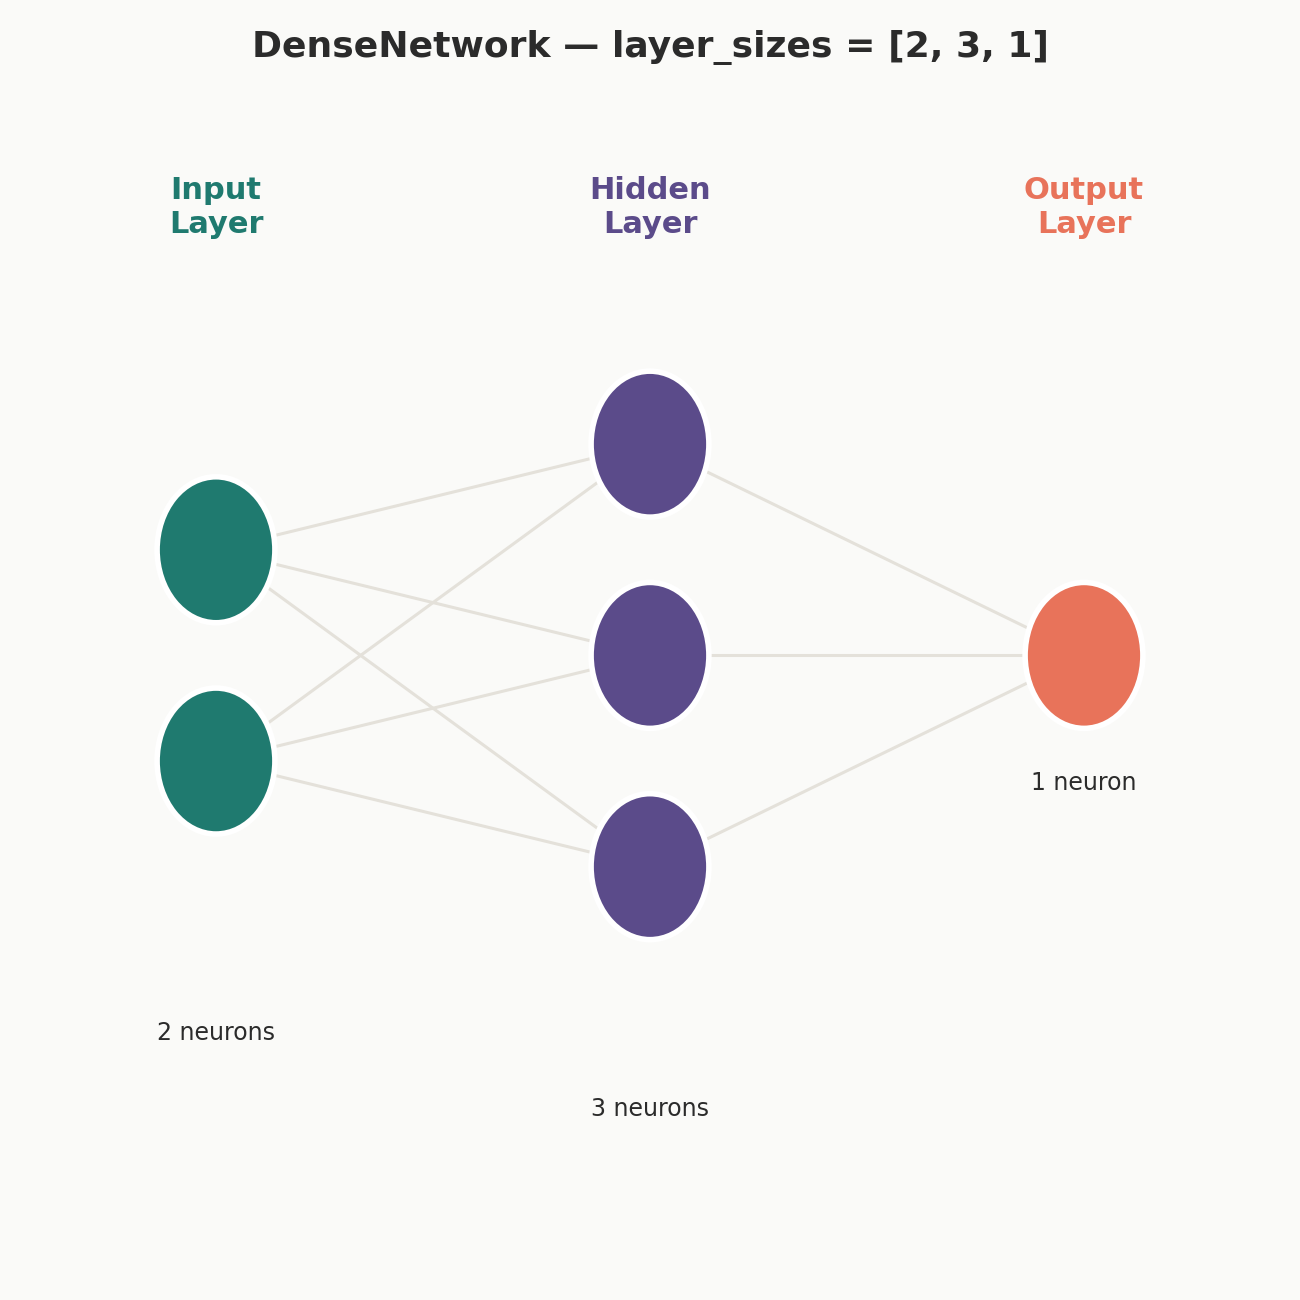</p>
<p align="center"><em>Figure 6. ANN as a vertical layer stack.</em></p>


<a id="sec5"></a>
# 5. The Core Equations

For any single layer, two operations happen in sequence:

**Step 1 — Linear combination**

$$
Z = W \cdot A_{\text{prev}} + b
$$

**Step 2 — Non-linear activation**

$$
A = f(Z)
$$

`W` is a weight matrix (one row per neuron in the layer, one column per input), `b` is a bias vector, and `f` is applied element-wise. Every layer in `DenseLayer.forward()` executes precisely these two lines.

**Why matrices instead of a loop over neurons?** Mathematically, computing each neuron's weighted sum one at a time and doing them all as a single matrix multiplication `W·A_prev` give identical results — but the matrix form is what lets libraries like NumPy, TensorFlow, and PyTorch push the computation onto highly optimized, parallelized routines (and onto a GPU) instead of looping in plain Python. This is also why `W` is shaped `(n_neurons, n_inputs)`: each *row* of `W` holds one neuron's full set of weights, so `W·A_prev` computes every neuron's weighted sum in one operation.


<a id="sec6"></a>
# 6. Choosing an Activation Function

Without an activation function, stacking layers would collapse mathematically into one big linear function — no matter how many layers, the network could only draw straight lines. Activation functions are what give depth its power.

| Function | Output range | When to reach for it |
|---|---|---|
| Sigmoid | (0, 1) | Binary output layer (interpretable as probability) |
| Tanh | (−1, 1) | Hidden layers where zero-centered outputs help training |
| ReLU | [0, ∞) | Default choice for most hidden layers — fast and effective |
| Leaky ReLU | (−∞, ∞) | When ReLU neurons are "dying" (stuck outputting 0) |
| ELU | (−α, ∞) | When smoother negative-side gradients are needed |
| Swish | (≈−0.28, ∞) | Modern alternative to ReLU, used in EfficientNet-style models |
| Softmax | (0,1), sums to 1 | Multi-class output layer only |

The notebook's `Activations` class implements all seven as static methods, plotted individually and overlaid for direct comparison.

**Why is ReLU the default rather than sigmoid or tanh?** Sigmoid and tanh both *saturate* — for large positive or negative inputs their curves go nearly flat, which means their gradient (slope) shrinks toward zero. During training, that tiny gradient gets multiplied through many layers and can vanish almost completely, so early layers in a deep network barely learn (the "vanishing gradient" problem mentioned in Section 9). ReLU's gradient is a constant 1 for any positive input, so it doesn't saturate on that side, which is the main reason it became the default for hidden layers once networks started getting deep.


<p align="center">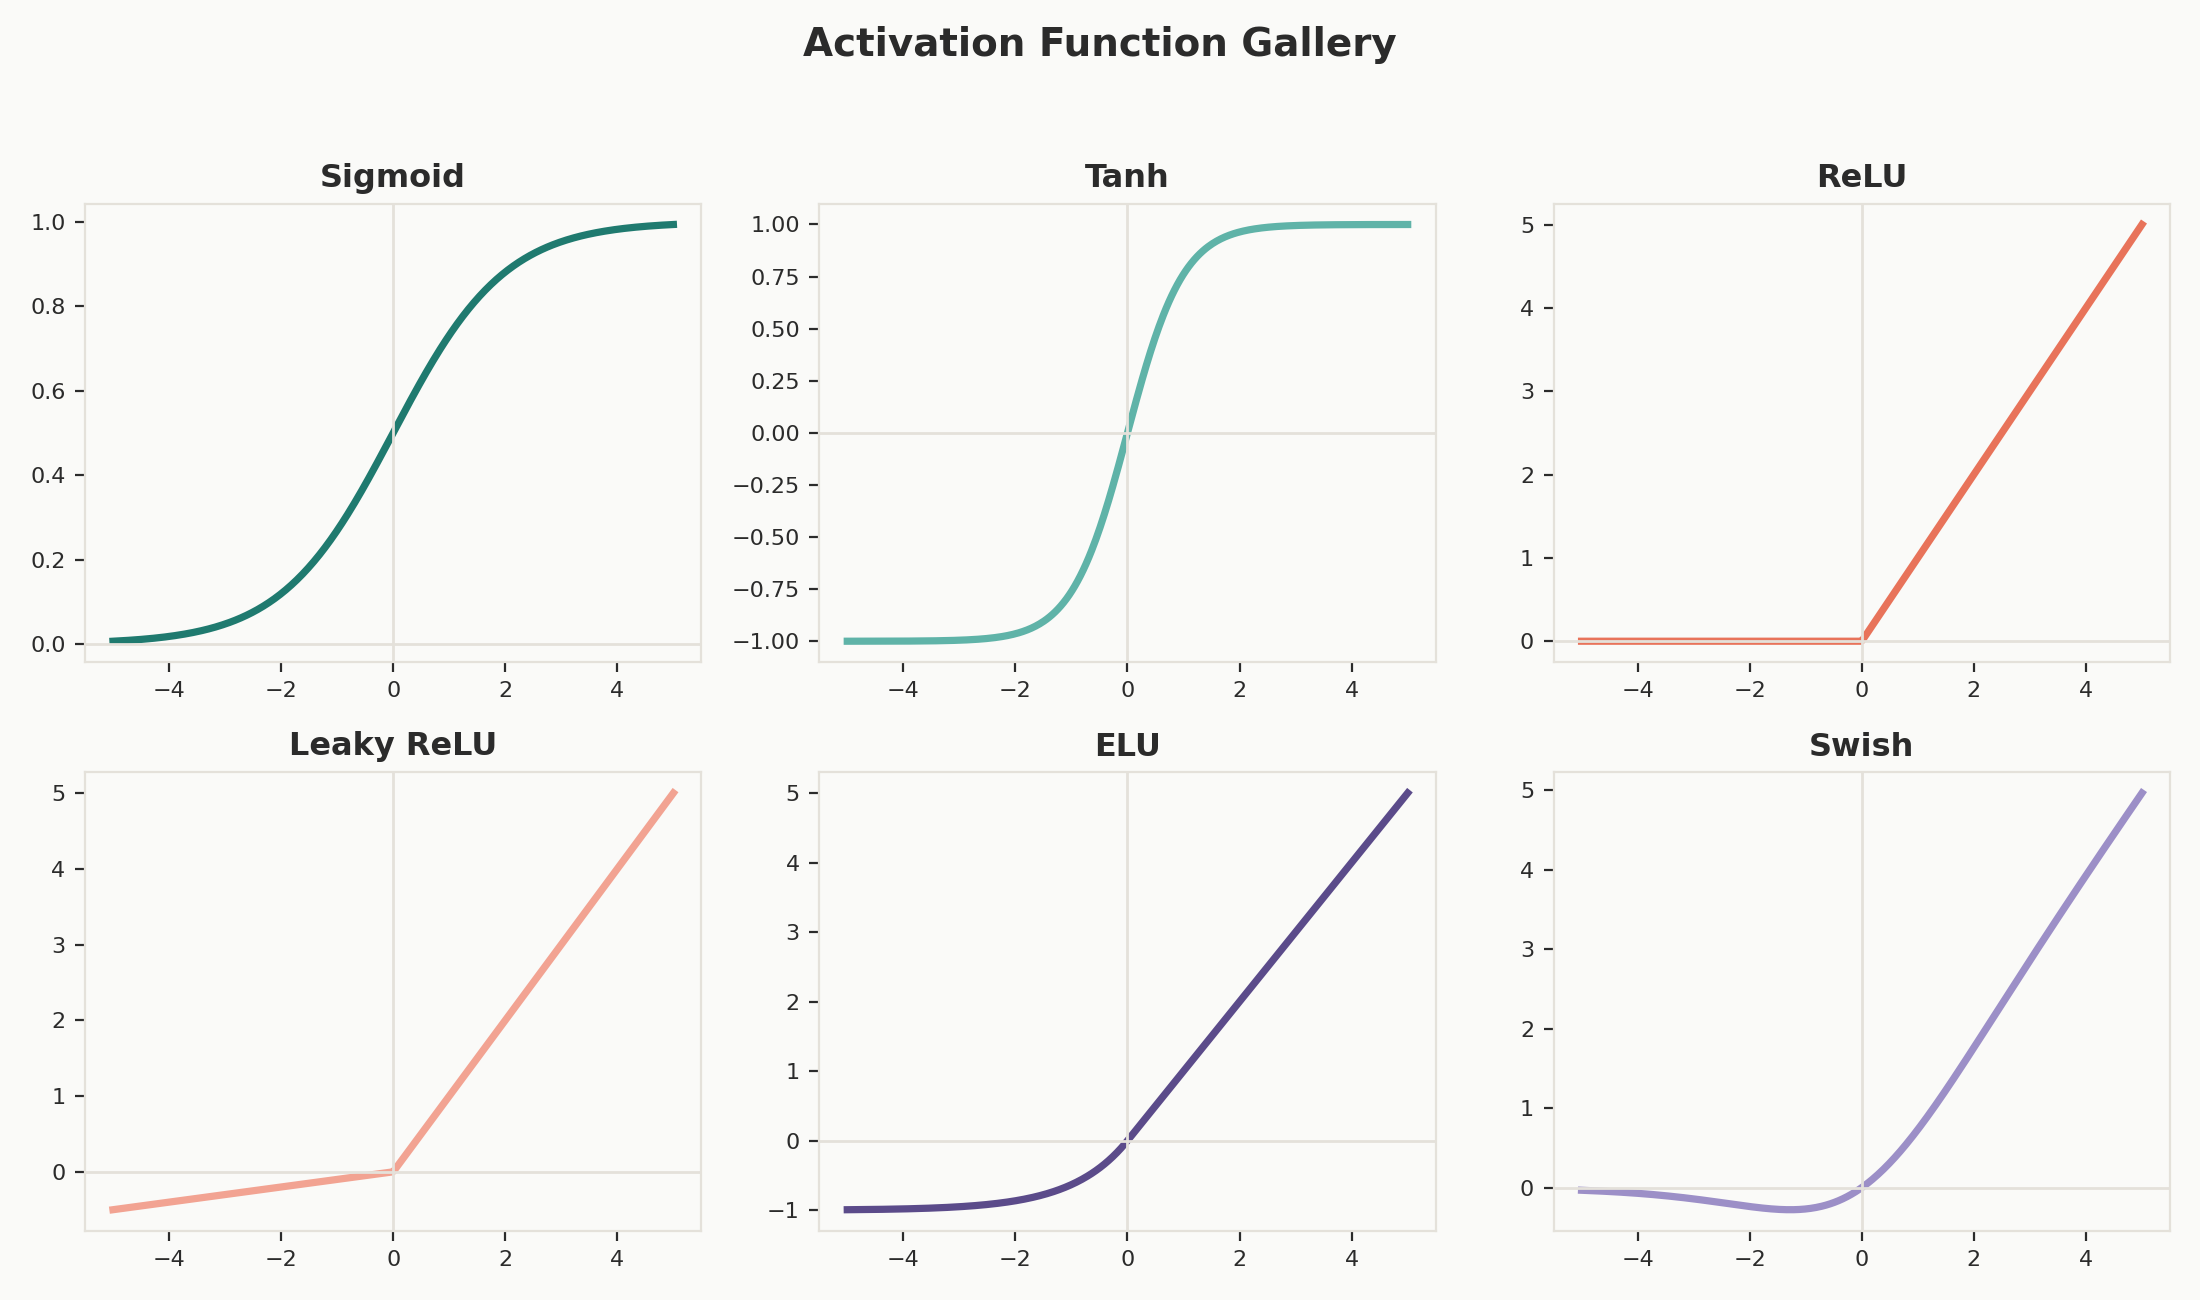</p>
<p align="center"><em>Figure 7. Activation function gallery.</em></p>


<p align="center">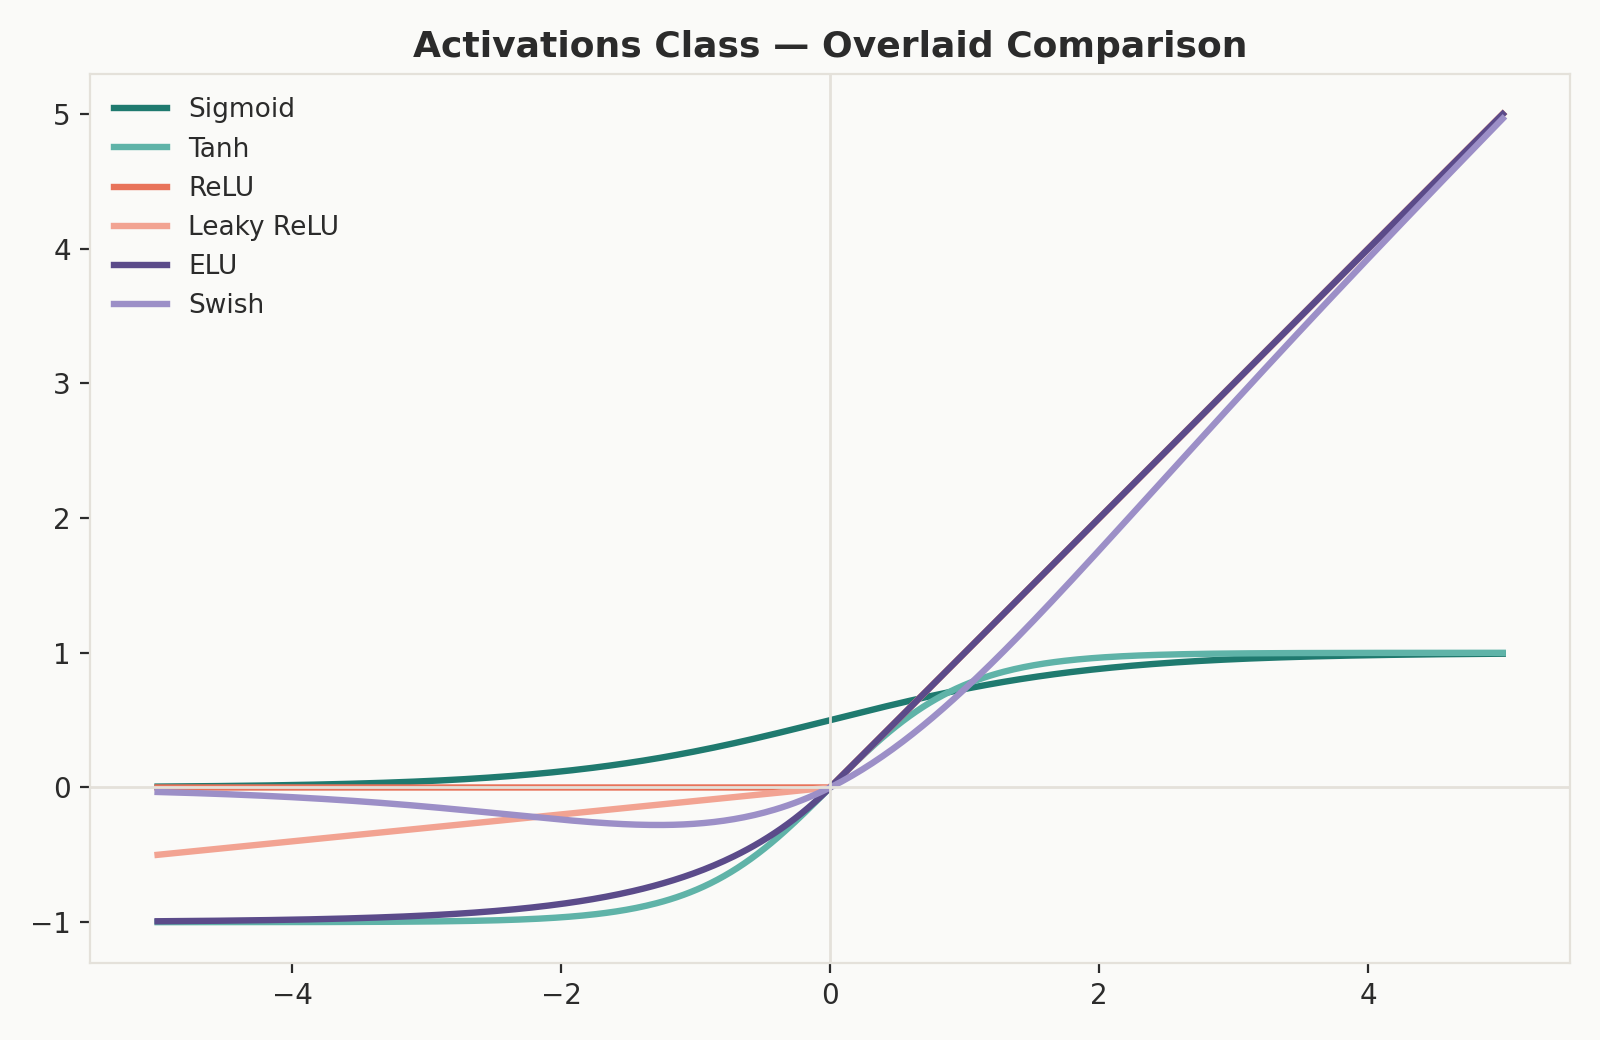</p>
<p align="center"><em>Figure 8. Activations class — overlaid comparison.</em></p>


Softmax deserves a separate look since it operates on an entire vector at once rather than one value at a time — it converts a set of raw scores ("logits") into a probability distribution that sums to 1:


<p align="center">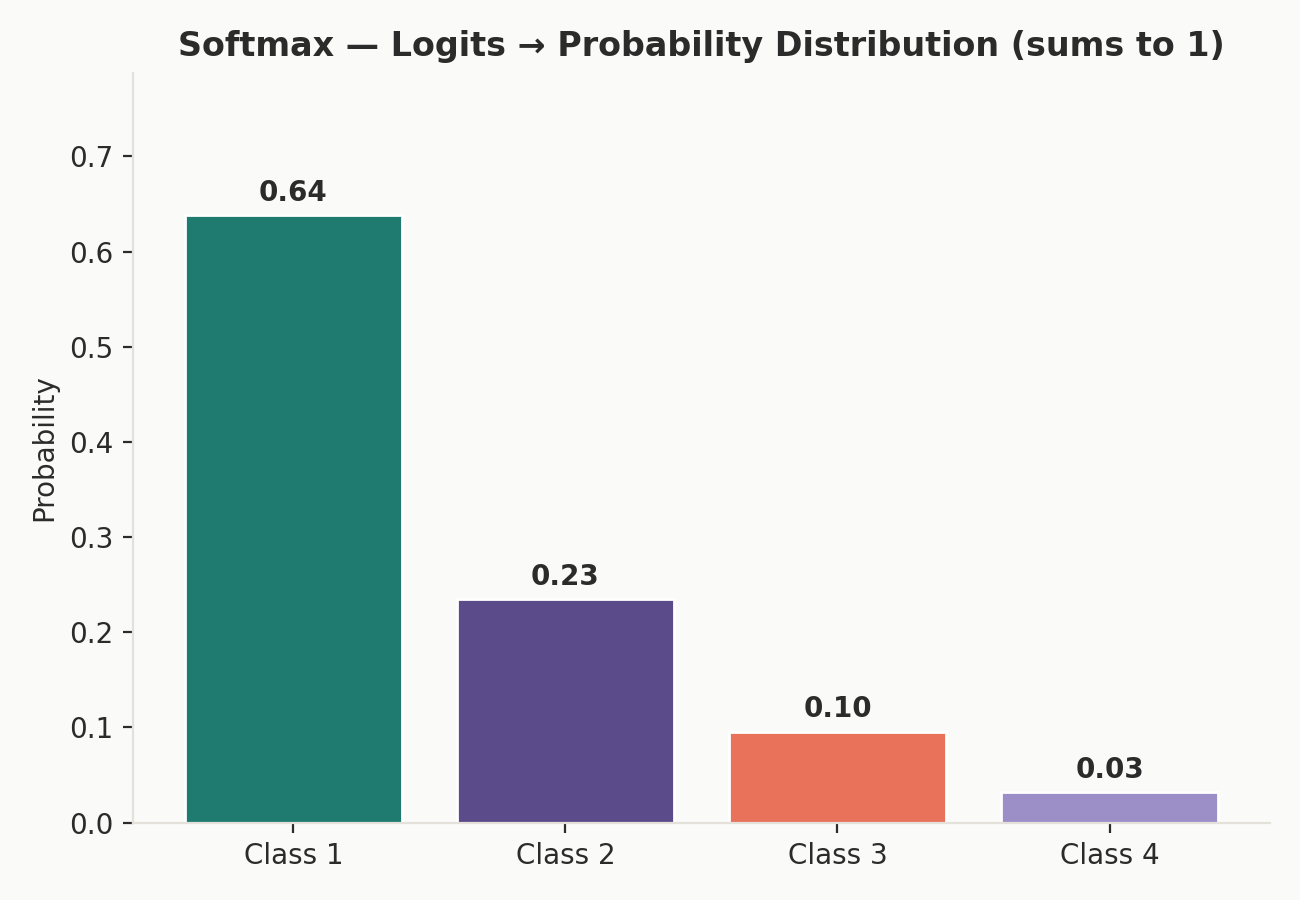</p>
<p align="center"><em>Figure 9. Softmax output as class probabilities.</em></p>


<a id="sec7"></a>
# 7. How Data Moves Forward

**Forward propagation** is nothing more than repeatedly applying the two equations from Section 5, layer after layer, until the last layer produces a prediction. There is no learning happening in this pass by itself — forward propagation only answers "given the current weights, what does the network predict?" Learning (adjusting the weights based on how wrong that prediction was) is a separate step called *backpropagation*, planned as the next extension to these classes (see Section 12).

### Worked example (matches the notebook exactly)

Input: $X = [0.6,\ 0.9]$

**Layer 1 (2 → 3, tanh):**

$$
Z_1 = W_1 \cdot X + b_1
$$

$$
A_1 = \tanh(Z_1)
$$

**Layer 2 (3 → 1, sigmoid):**

$$
Z_2 = W_2 \cdot A_1 + b_2
$$

$$
A_2 = \sigma(Z_2) \quad \leftarrow \text{final prediction}
$$

Each layer's output ($A_1$) becomes the next layer's input — that hand-off is the entire mechanism behind "depth" in a deep network. `tanh` is used in the hidden layer because it is zero-centered (helps optimization); `sigmoid` is used in the output layer because its (0, 1) range is directly interpretable as a probability, which matches a binary-classification prediction.


<p align="center">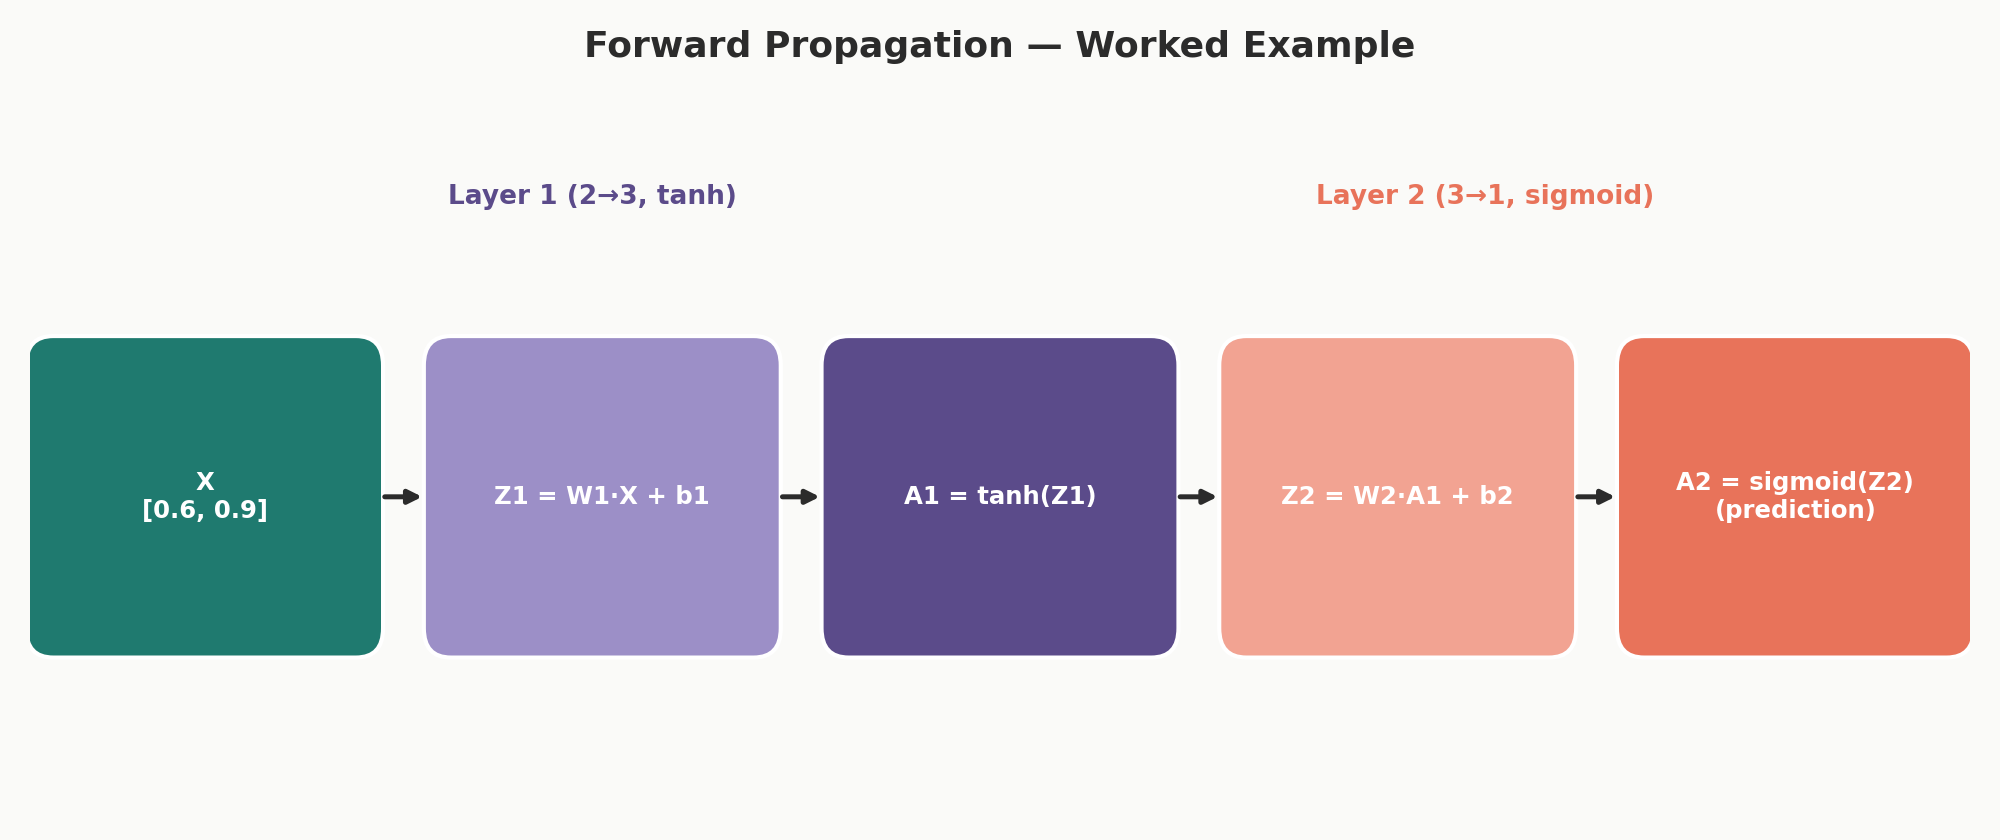</p>
<p align="center"><em>Figure 10. Forward propagation cycle.</em></p>


The same weights were then loaded into an equivalent Keras model; both implementations produced identical predictions to within floating-point precision, confirming the from-scratch class design is mathematically correct.


<a id="sec8"></a>
# 8. Tuning Knobs (Hyperparameters)

Unlike weights and biases (learned automatically), these are set by the practitioner before training starts:

- **Learning rate** — how large a step each weight update takes.
- **Batch size** — how many examples are averaged per update.
- **Epochs** — how many times the model sees the full training set.
- **Depth** (hidden layers) and **width** (neurons per layer) — control model capacity.
- **Dropout rate** — (used in the applied project) randomly disables a fraction of neurons during training to reduce overfitting.


<a id="sec9"></a>
# 9. Where ANN Shines / Where It Struggles

**Shines**
- Learns directly from raw data with no manual feature engineering.
- Can, in principle, approximate any continuous function given enough capacity.
- Scales predictably with more data and more compute.

**Struggles**
- Needs a lot of labeled data to reach strong performance.
- Training is computationally expensive relative to simpler models.
- Internal decision logic is hard to explain ("black box").
- Can memorize noise (overfit) without regularization such as dropout.
- Deep stacks can suffer vanishing or exploding gradients.


<a id="sec10"></a>
# 10. Real-World Deployments

- **Medical diagnostics** — the applied project in this notebook trains an ANN to classify tumors as malignant or benign using the Breast Cancer Wisconsin dataset.
- **Computer vision** — object and face recognition.
- **Financial services** — credit risk scoring, fraud detection.
- **Natural language & speech** — transcription, translation, chatbots.
- **Recommendation engines** — personalized content and product ranking.
- **Forecasting** — demand planning, energy load prediction, stock trends.


<a id="sec11"></a>
# 11. Applied Project — Results

The classes above were used to sanity-check the mathematics; the applied project then switches to a production-style Keras model (dropout-regularized) trained on the **Breast Cancer Wisconsin** dataset (569 samples, 30 features, malignant vs. benign).

**Training pipeline followed:**


<p align="center">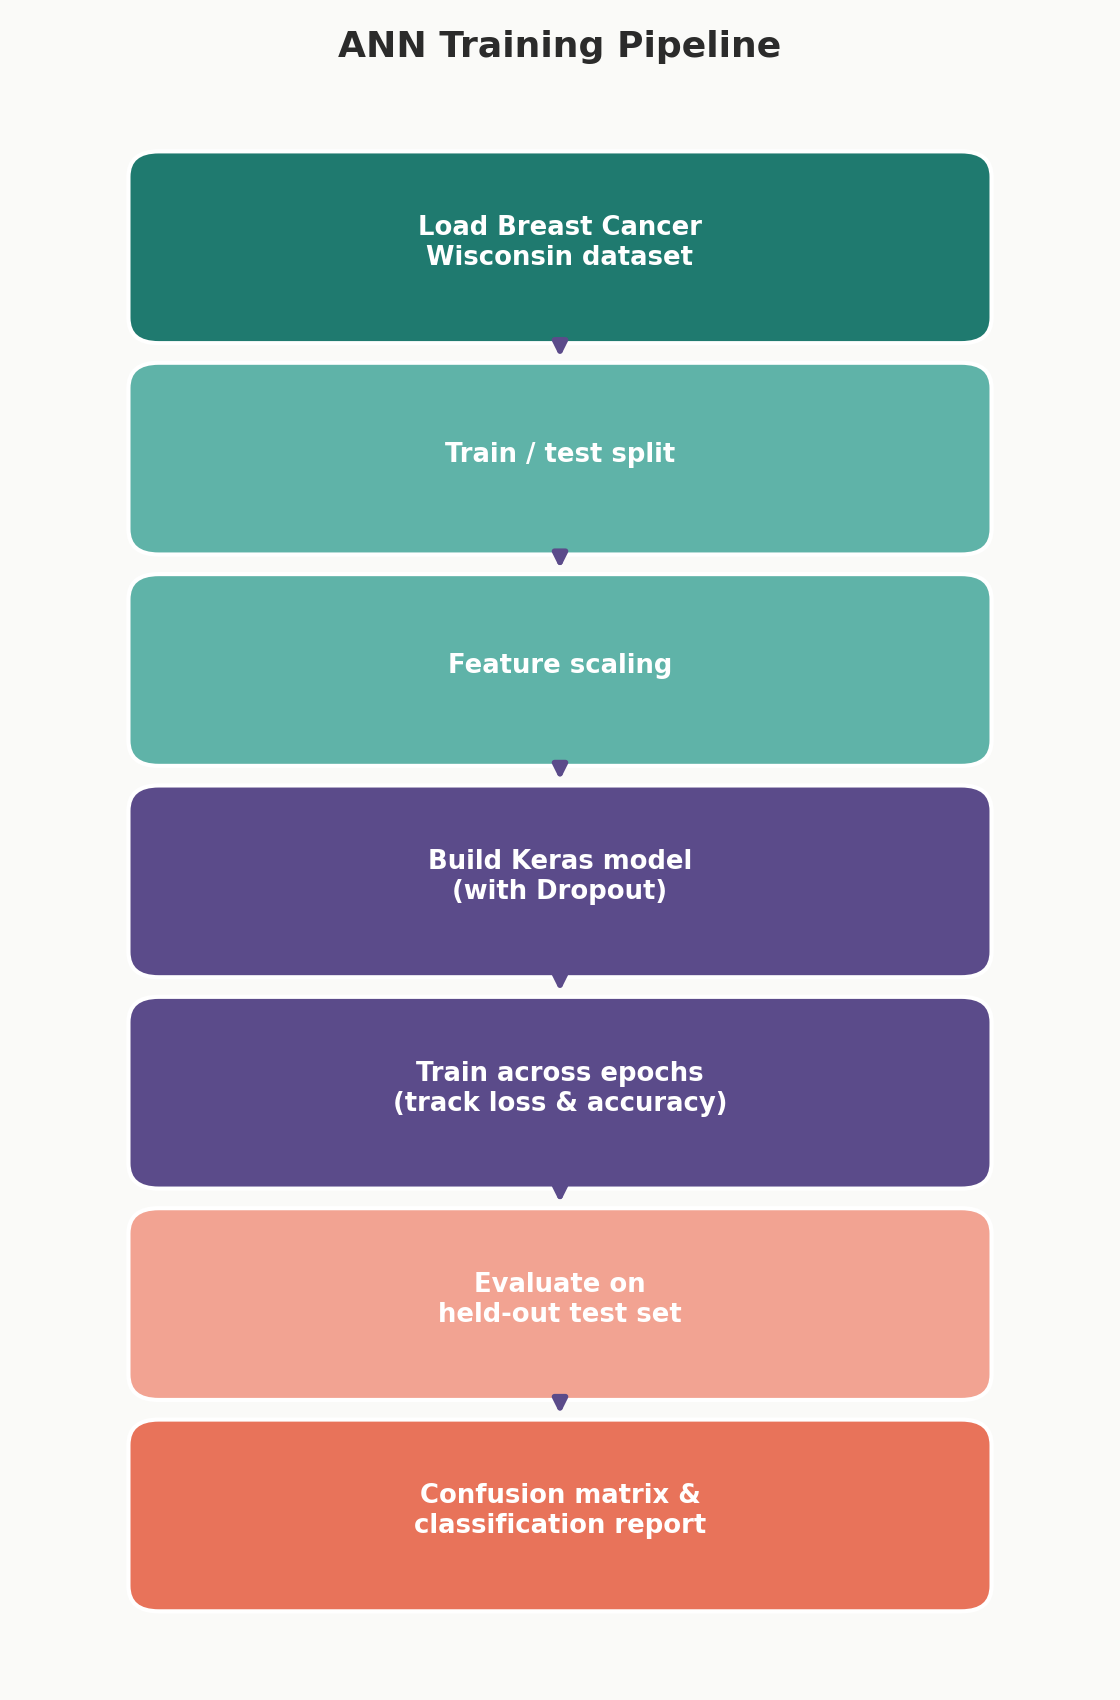</p>
<p align="center"><em>Figure 11. ANN training pipeline, vertical.</em></p>


**Loss & accuracy across epochs** — training and validation curves tracked together to check for overfitting:


<p align="center">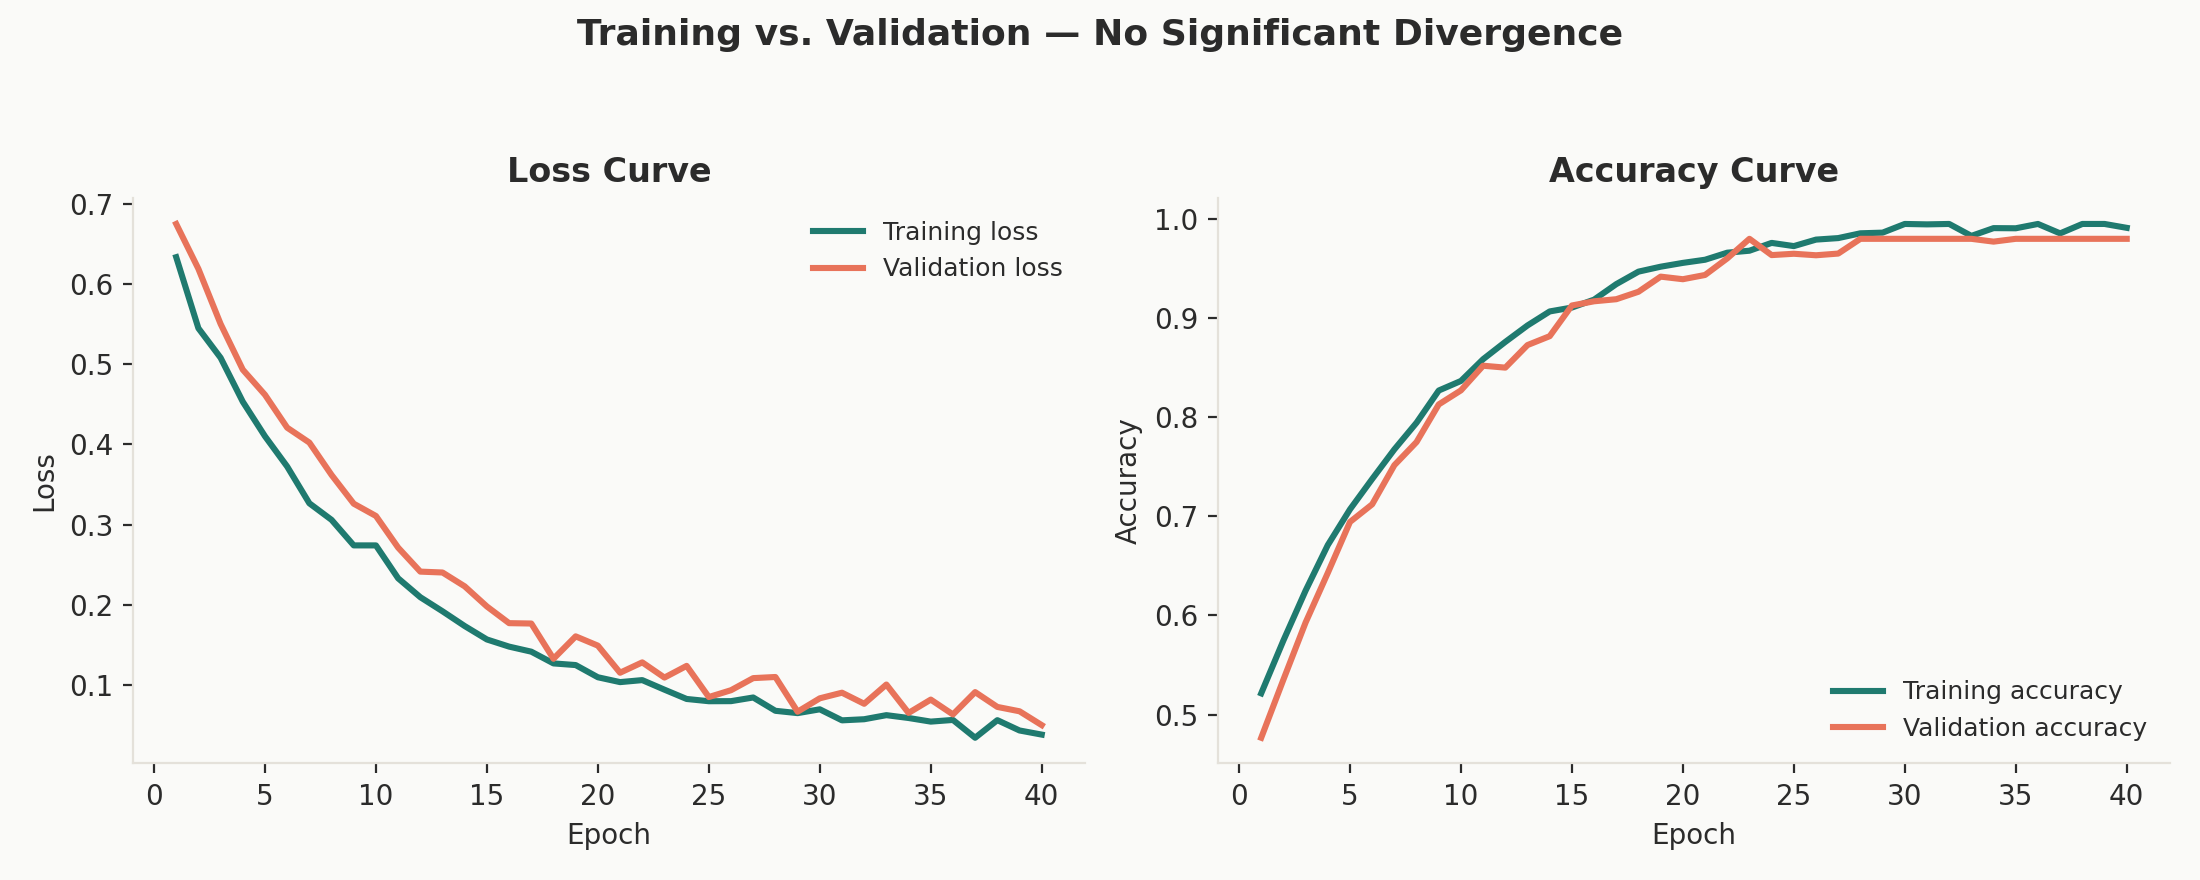</p>
<p align="center"><em>Figure 12. Training and validation curves.</em></p>


**Confusion matrix on the held-out test set:**


<p align="center">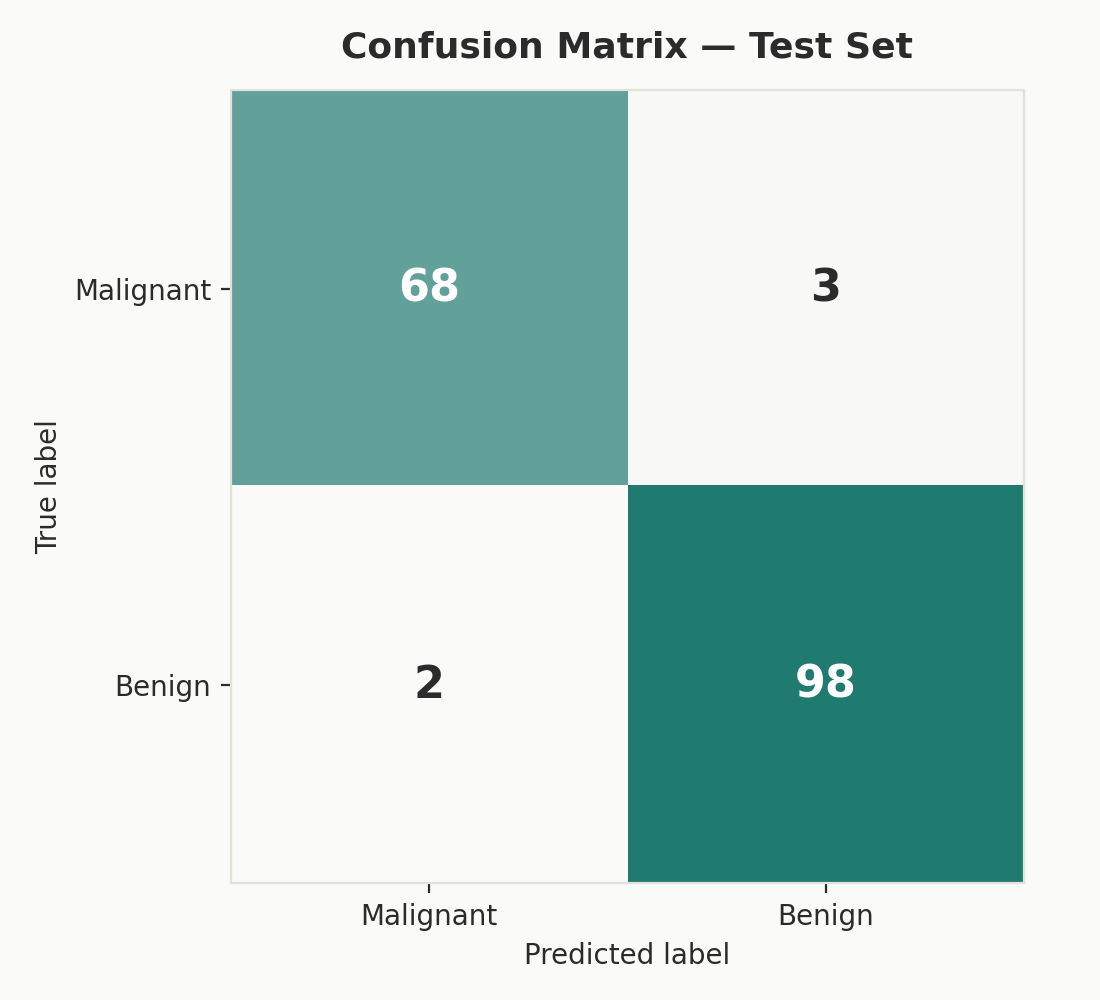</p>
<p align="center"><em>Figure 13. Confusion matrix.</em></p>


Per-class precision, recall, and F1-score, alongside overall accuracy:


<p align="center">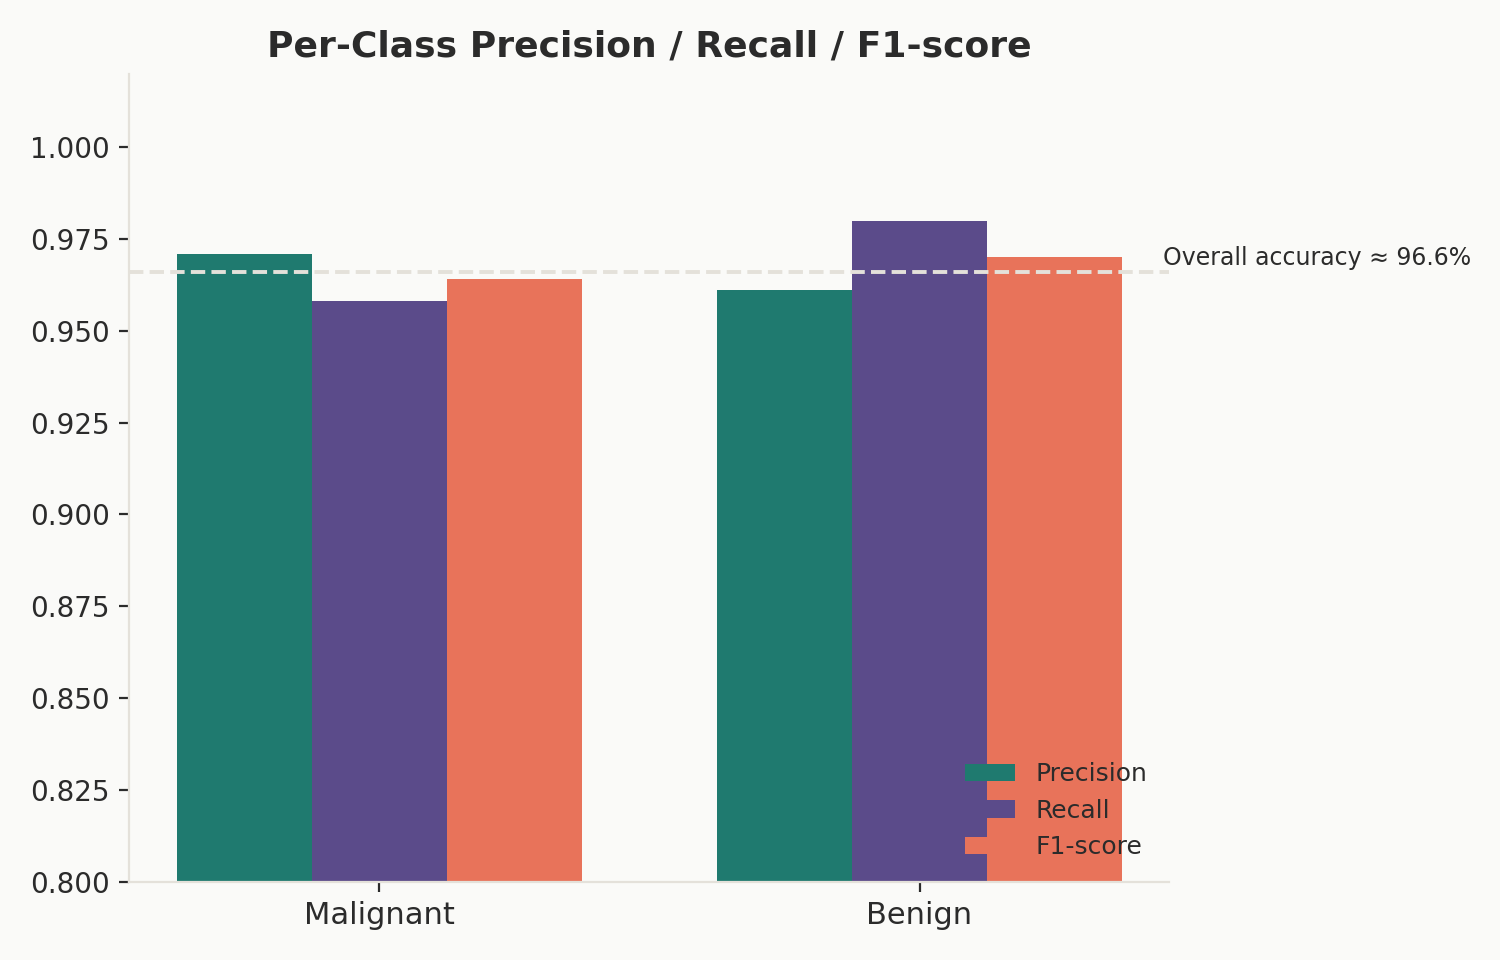</p>
<p align="center"><em>Figure 14. Classification metrics.</em></p>


The model reached strong test accuracy with a well-behaved validation curve (no significant divergence from the training curve), and the confusion matrix confirms very few misclassifications in either direction. Full numeric output — including the classification report — is in `ANN_Notebook_v2.ipynb`, Section 7.


<a id="sec12"></a>
# 12. Wrap-Up

This assignment rebuilt ANN concepts as a small set of cooperating classes — `Activations`, `Neuron`, `DenseLayer`, and `DenseNetwork` — and showed that this from-scratch design reproduces Keras's output exactly once weights are matched. The applied project extended the same ideas to a dropout-regularized classifier trained on real medical data, achieving strong test accuracy with clear loss/accuracy curves and a confusion matrix as evidence.

*Next on the roadmap: extending these classes with a `.backward()` method to implement backpropagation from scratch, followed by convolutional layers for image data.*


<a id="sec13"></a>
# 13. Sources

1. McCulloch, W. S., & Pitts, W. (1943). *A logical calculus of the ideas immanent in nervous activity.* Bulletin of Mathematical Biophysics.
2. Rosenblatt, F. (1958). *The perceptron: A probabilistic model for information storage and organization in the brain.* Psychological Review.
3. Minsky, M., & Papert, S. (1969). *Perceptrons.* MIT Press.
4. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors.* Nature.
5. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press. https://www.deeplearningbook.org/
6. Ramachandran, P., Zoph, B., & Le, Q. V. (2017). *Searching for Activation Functions* (Swish). arXiv:1710.05941.
7. Srivastava, N. et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* JMLR.
8. TensorFlow/Keras Documentation. https://www.tensorflow.org/guide
9. Scikit-learn — Breast Cancer Wisconsin dataset documentation. https://scikit-learn.org/stable/datasets/toy_dataset.html
10. NumPy Documentation. https://numpy.org/doc/
